In [217]:
import numpy as np
import matplotlib.pyplot as plt
from tf_keras.datasets import mnist
import tensorflow as tf
from tf_keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tf_keras.models import load_model, clone_model
from tf_keras.models import Model
import tf_keras as keras
from copy import copy, deepcopy
from tf_keras.layers import *
from tf_keras.utils import to_categorical



In [218]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [219]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

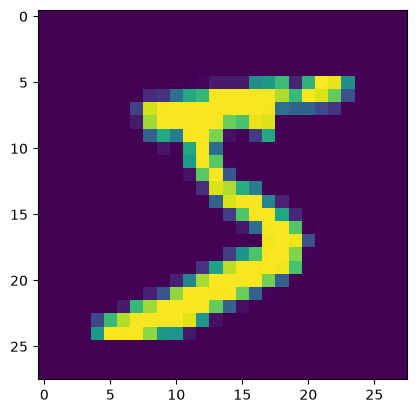

In [220]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [221]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


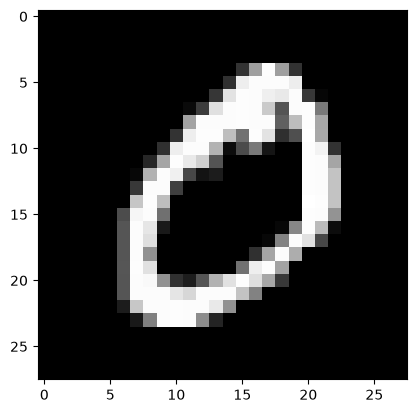

Label = 1


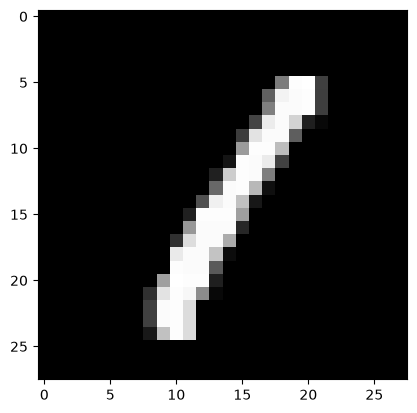

Label = 2


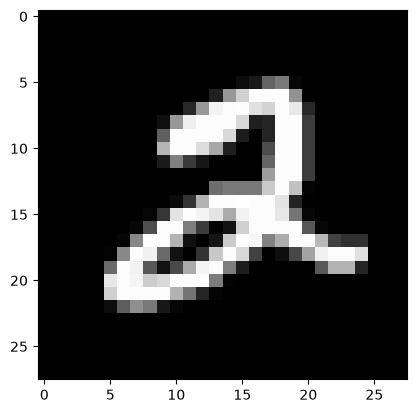

Label = 3


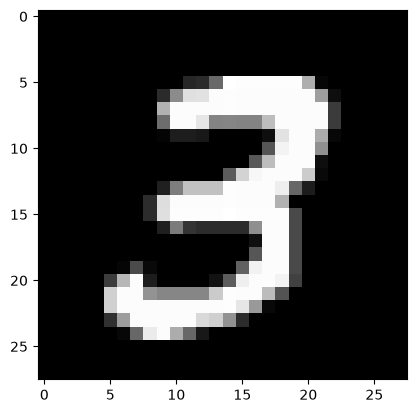

Label = 4


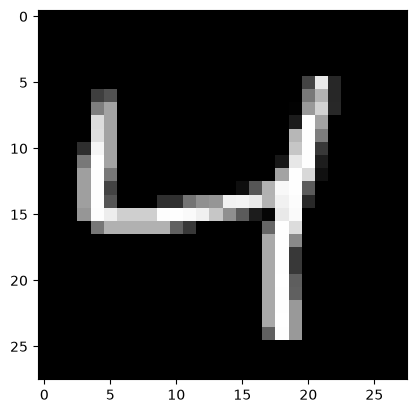

Label = 5


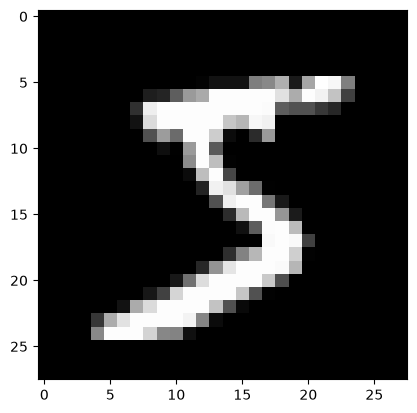

Label = 6


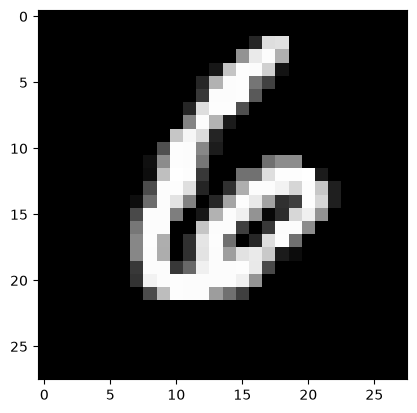

Label = 7


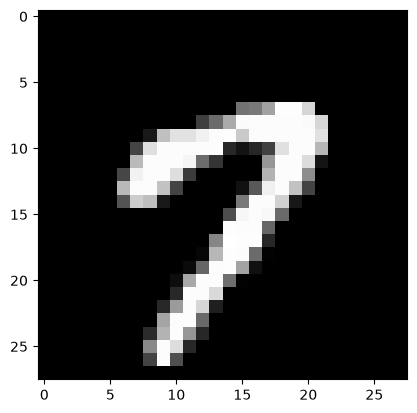

Label = 8


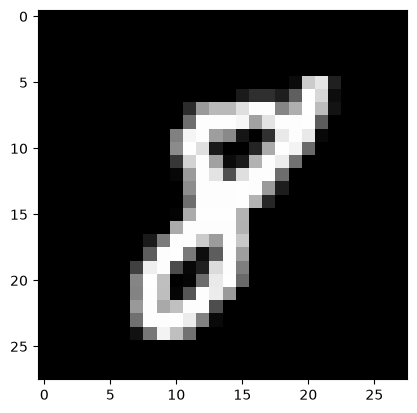

Label = 9


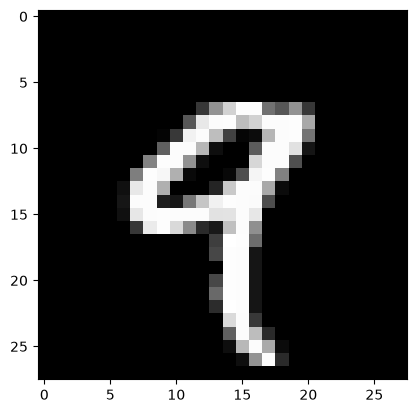

In [222]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx],cmap = 'gray')
            plt.show()
            break
    

In [223]:
# 32 Floating Point data type is used
mem_fig = 28 * 28 * 4 / 1024  # 784 pixels × 4 bytes (float32), converted to KB
print('The required memory useage for each figure is:{} kb' .format(mem_fig) )

The required memory useage for each figure is:3.0625 kb


# Construct the MLP

In [224]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [225]:
# Build up the MLP
# later you can change the number of neurons and layers

input_layer = Input(shape= data_train[0].shape)
input_layer_f = Flatten()(input_layer)

hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

model = Model(input_layer, output_layer_act)


In [226]:
parameter_by_layer = np.zeros([4])

# layer 1: Dense(5) with 784 inputs → 784*5 weights + 5 biases
parameter_by_layer[0] = 784 * 5 + 5
# layer 2: Dense(8) with 5 inputs → 5*8 weights + 8 biases
parameter_by_layer[1] = 5 * 8 + 8
# layer 3: Dense(8) with 8 inputs → 8*8 weights + 8 biases
parameter_by_layer[2] = 8 * 8 + 8
# layer 4: Dense(10) with 8 inputs → 8*10 weights + 10 biases
parameter_by_layer[3] = 8 * 10 + 10

mem_model = parameter_by_layer.sum() * 4 / 1024  # 4 bytes per float32, convert to KB

print('The total memory usage for weights and bias is {} kb' .format(mem_model))

The total memory usage for weights and bias is 16.15234375 kb


In [227]:
# check the parameter numbers
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 3925      
                                                                 
 act_1 (Activation)          (None, 5)                 0         
                                                                 
 dense_2 (Dense)             (None, 8)                 48        
                                                                 
 act_2 (Activation)          (None, 8)                 0         
                                                                 
 dense_3 (Dense)             (None, 8)                 72  

# Model Training

In [228]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
print(tf.config.list_physical_devices())

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [229]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is recommended (10)
r= model.fit(data_train, label_train,  validation_split= 0.2, epochs=10)

Epoch 1/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.8993 - accuracy: 0.7013 - val_loss: 0.4672 - val_accuracy: 0.8687
Epoch 2/10
1500/1500 [==============================] - 2s 2ms/step - loss: 0.4469 - accuracy: 0.8716 - val_loss: 0.3937 - val_accuracy: 0.8875
Epoch 3/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.4010 - accuracy: 0.8841 - val_loss: 0.3703 - val_accuracy: 0.8933
Epoch 4/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.3795 - accuracy: 0.8908 - val_loss: 0.3600 - val_accuracy: 0.8943
Epoch 5/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.3666 - accuracy: 0.8951 - val_loss: 0.3566 - val_accuracy: 0.8971
Epoch 6/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.3548 - accuracy: 0.8980 - val_loss: 0.3460 - val_accuracy: 0.9006
Epoch 7/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.3485 - accuracy: 0.9001 - val_loss: 0.3591 - val_accuracy:

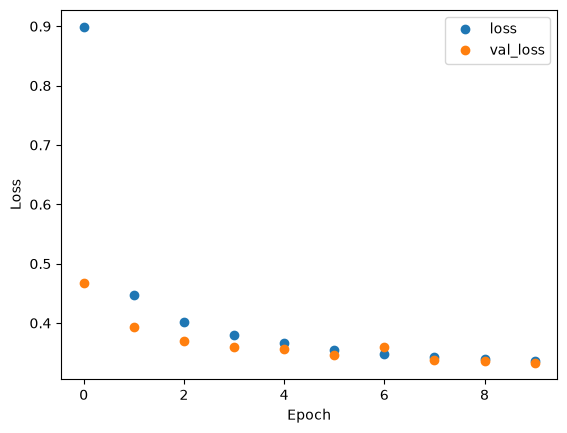

In [230]:
# plot loss
plt.plot(r.history['loss'],  'o', label='loss')
plt.plot(r.history['val_loss'],'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

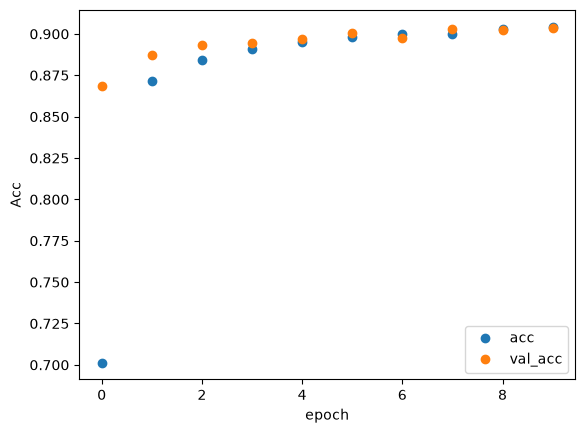

In [231]:
# Plot accuracy
acc_key     = 'accuracy'     if 'accuracy'     in r.history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in r.history else 'val_acc'
plt.plot(r.history[acc_key],     'o', label='acc')
plt.plot(r.history[val_acc_key], 'o', label='val_acc')
plt.xlabel('epoch')
plt.ylabel('Acc')
plt.legend()
plt.show()


In [232]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Train Acc", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Test Acc:",acc_floatingpoint )

1875/1875 [==============================] - 2s 1ms/step - loss: 0.3249 - accuracy: 0.9071
Train Acc 0.9071499705314636
313/313 [==============================] - 0s 1ms/step - loss: 0.3477 - accuracy: 0.9000
Test Acc: 0.8999999761581421


In [233]:
# save model weights
model.save_weights("weights_floatingpoint.weights.h5")

In [234]:
# Keep a pristine, independent copy of the trained floating-point weights.
# IMPORTANT: from now on, use `original_weights` (not model.get_weights()) as the
# source for quantization. Building a Model(...) that reuses the same layer
# objects as `model` (as done further below) makes it share the same weight
# variables, so calling set_weights() on it would silently overwrite model's
# weights too. Using this saved copy protects us from that side effect.
original_weights = [w.copy() for w in model.get_weights()]


Text(0, 0.5, 'Number')

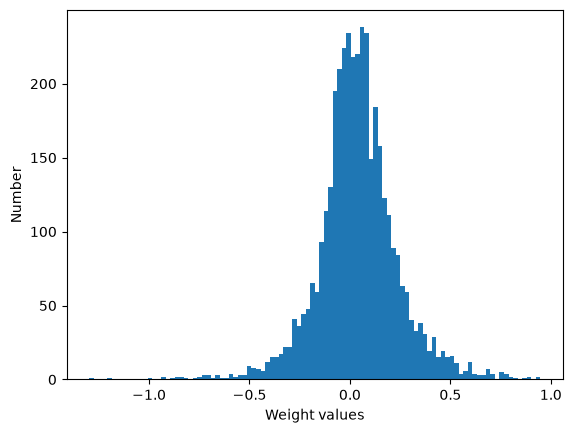

In [235]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Number')

In [236]:
# What can you observe from the distribution of weights?

# Implement of the trained MLP with numpy

In [237]:
# implement the dense layer
def dense_layer(input_mat, input_vec, bias):
    result = np.dot(input_mat, input_vec) + bias
    return result

In [238]:
# implement the ReLU activation function
def ReLU_layer(in_activations):
    out_activations = np.zeros(in_activations.shape)
    for i in range(len(in_activations)):
        if in_activations[i] > 0:
            out_activations[i] = in_activations[i]
    return out_activations

In [239]:
# implement the softmax activation function
def softmax_layer(in_activations):
    out_activations = np.zeros(in_activations.shape)
    exp_vals = np.exp(in_activations)
    for i in range(len(in_activations)):
       out_activations[i] = exp_vals[i] / exp_vals.sum()
    return out_activations

In [240]:
# implement your own MLP, the weighs & biases should be extracted by model.get_weights()
# the softmax layer is not necessary to be implemented
weights = model.get_weights()  # [W1, b1, W2, b2, W3, b3, W4, b4]
input_example_np = np.ones([28 * 28])
output_1 = ReLU_layer(dense_layer(input_example_np, weights[0], weights[1]))
output_2 = ReLU_layer(dense_layer(output_1,        weights[2], weights[3]))
output_3 = ReLU_layer(dense_layer(output_2,        weights[4], weights[5]))
output_4 = softmax_layer(dense_layer(output_3,     weights[6], weights[7]))

In [241]:
# Display your own results
output_4

array([3.43662845e-15, 1.40119414e-30, 9.45820132e-10, 9.99762426e-01,
       8.58644629e-74, 8.17747465e-06, 2.24640990e-32, 1.02332405e-54,
       2.29395231e-04, 1.34504757e-50])

In [242]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 [==============================] - 0s 44ms/step


array([[3.4366716e-15, 1.4012156e-30, 9.4584784e-10, 9.9976236e-01,
        0.0000000e+00, 8.1772987e-06, 2.2464404e-32, 0.0000000e+00,
        2.2939499e-04, 0.0000000e+00]], dtype=float32)

# MLP fixed point quantization

In [243]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference acc. with TF model
# Estimate how much memory storage you can save with quantization 

In [244]:
# function to quantize weights with speficied bit width for integer and fractional part
def fixP_quantization(input_weight, int_BW, frac_BW):
    resolution_ = 2 ** (-frac_BW)           # smallest representable step
    range_       = 2 ** int_BW               # sign bit included → range is [-range_, range_)
    
    weight = deepcopy(input_weight)
    
    input_weight_clipped    = np.clip(weight, -range_, range_ - resolution_)
    input_weight_quantized  = np.round(input_weight_clipped / resolution_) * resolution_
    
    return input_weight_quantized


In [245]:
# weight_quantization — try different combinations to explore the accuracy/memory trade-off
BW_int  = 2   # integer bits (sign bit is separate)
BW_frac = 5   # fractional bits → total: 1+2+5 = 8-bit fixed point


In [246]:
weight_quantized = [deepcopy(w) for w in original_weights]

In [247]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

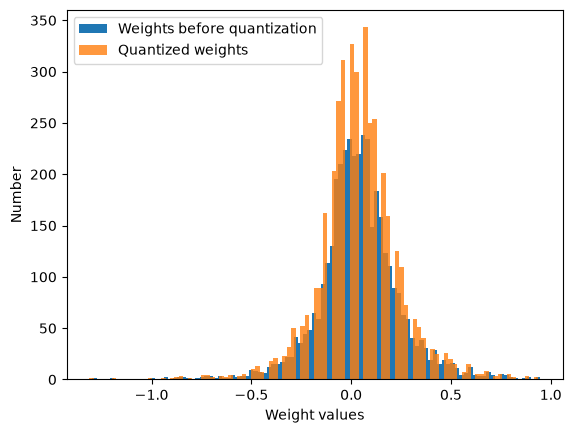

In [248]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [249]:
# define the quantized model
# NOTE: use clone_model(), NOT Model(input_layer, output_layer_act).
# Reusing the same layer objects would make model_quantized share model's
# weight variables, so set_weights() below would also overwrite model's weights.
model_quantized = clone_model(model)

In [250]:
# load weights and save
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5".format(BW_int, BW_frac))

# Evaluation of the quantization 

In [251]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [252]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 [==============================] - 2s 1ms/step - loss: 0.3265 - accuracy: 0.9057
Train Acc 0.9056666493415833
313/313 [==============================] - 0s 1ms/step - loss: 0.3497 - accuracy: 0.8959
Test Acc: 0.8959000110626221


In [253]:
# Summary
# 32 FP numbers utilized in baseline model
total_bits_quantized = 1 + BW_int + BW_frac  # sign + integer + fractional bits
saved_memory = 1 - total_bits_quantized / 32
acc_drop = acc_floatingpoint - acc_quantized

In [254]:
print("Saved memory: {}% ".format(saved_memory*100))
print("Accuracy drop: {:.2f}%" .format(acc_drop*100))

Saved memory: 75.0% 
Accuracy drop: 0.41%


In [255]:
def optimal_combination():
    results = []  # collect (frac_bits, total_bits, acc_quantized, acc_drop, saved_memory)
    for frac in range(0, 15):
        print("Trying with fractional bits = {}".format(frac))
        BW_int  = 1
        BW_frac = frac
        weight_quantized = [deepcopy(w) for w in original_weights]
        for j in range(len(weight_quantized)):
            weight_quantized[j] = fixP_quantization(np.copy(weight_quantized[j]), BW_int, BW_frac)

        model_quantized = clone_model(model)
        model_quantized.set_weights(weight_quantized)
        model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5".format(BW_int, BW_frac))
        model_quantized.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
        print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
        acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
        print("Test Acc:", acc_quantized)
        total_bits_quantized = 1 + BW_int + BW_frac
        saved_memory = 1 - total_bits_quantized / 32
        acc_drop = acc_floatingpoint - acc_quantized
        print("Saved memory: {}% ".format(saved_memory * 100))
        print("Accuracy drop: {}%".format(acc_drop * 100))
        results.append({
            "frac_bits":    BW_frac,
            "total_bits":   total_bits_quantized,
            "acc_quantized": acc_quantized,
            "acc_drop":     acc_drop,
            "saved_memory": saved_memory,
        })
    return results

results = optimal_combination()


Trying with fractional bits = 0


1875/1875 [==============================] - 2s 1ms/step - loss: 4.1273 - accuracy: 0.1186
Train Acc 0.11860000342130661
313/313 [==============================] - 0s 1ms/step - loss: 4.1437 - accuracy: 0.1182
Test Acc: 0.11819999665021896
Saved memory: 93.75% 
Accuracy drop: 78.17999795079231%
Trying with fractional bits = 1
1875/1875 [==============================] - 2s 1ms/step - loss: 3.4235 - accuracy: 0.2444
Train Acc 0.2443999946117401
313/313 [==============================] - 0s 1ms/step - loss: 3.3653 - accuracy: 0.2418
Test Acc: 0.241799995303154
Saved memory: 90.625% 
Accuracy drop: 65.81999808549881%
Trying with fractional bits = 2
1875/1875 [==============================] - 2s 1ms/step - loss: 1.8950 - accuracy: 0.5745
Train Acc 0.5745166540145874
313/313 [==============================] - 0s 1ms/step - loss: 1.9532 - accuracy: 0.5633
Test Acc: 0.5633000135421753
Saved memory: 87.5% 
Accuracy drop: 33.66999626159668%
Trying with fractional bits = 3
1875/1875 [==========

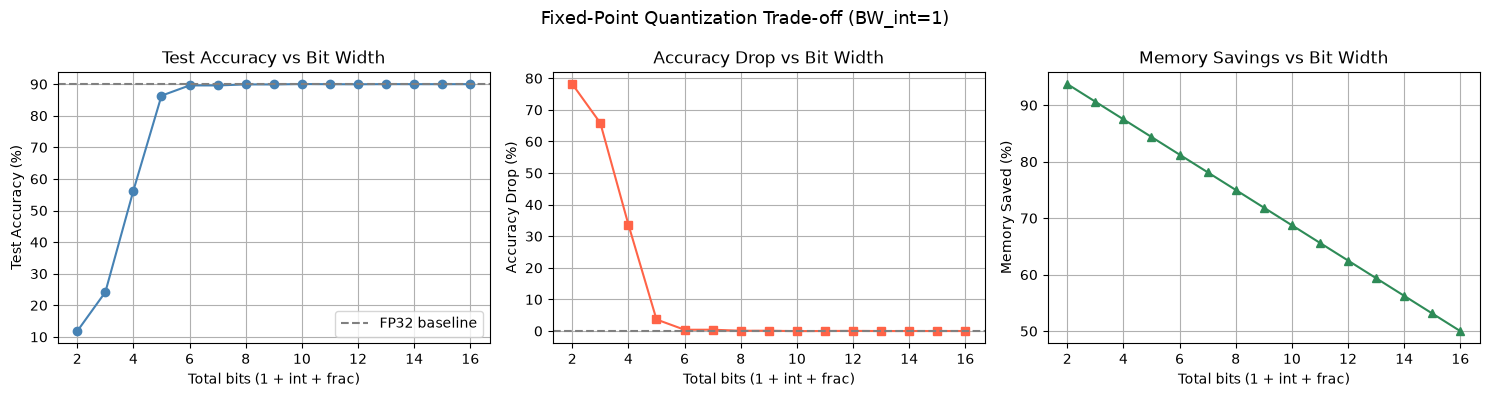

In [256]:
frac_bits    = [r["frac_bits"]    for r in results]
total_bits   = [r["total_bits"]   for r in results]
acc_q        = [r["acc_quantized"] * 100 for r in results]
acc_drop_pct = [r["acc_drop"]     * 100 for r in results]
saved_mem    = [r["saved_memory"] * 100 for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Test Accuracy vs Total Bits ---
axes[0].plot(total_bits, acc_q, 'o-', color='steelblue')
axes[0].axhline(acc_floatingpoint * 100, color='gray', linestyle='--', label='FP32 baseline')
axes[0].set_xlabel('Total bits (1 + int + frac)')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy vs Bit Width')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Accuracy Drop vs Total Bits ---
axes[1].plot(total_bits, acc_drop_pct, 's-', color='tomato')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Total bits (1 + int + frac)')
axes[1].set_ylabel('Accuracy Drop (%)')
axes[1].set_title('Accuracy Drop vs Bit Width')
axes[1].grid(True)

# --- Plot 3: Memory Savings vs Total Bits ---
axes[2].plot(total_bits, saved_mem, '^-', color='seagreen')
axes[2].set_xlabel('Total bits (1 + int + frac)')
axes[2].set_ylabel('Memory Saved (%)')
axes[2].set_title('Memory Savings vs Bit Width')
axes[2].grid(True)

plt.suptitle('Fixed-Point Quantization Trade-off (BW_int=1)', fontsize=13)
plt.tight_layout()
plt.show()


# Pruning

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 prune_low_magnitude_flatte  (None, 784)               1         
 n_2 (PruneLowMagnitude)                                         
                                                                 
 prune_low_magnitude_dense_  (None, 5)                 7847      
 1 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_act_1   (None, 5)                 1         
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 90        
 2 (PruneLowMagnitude)                                     

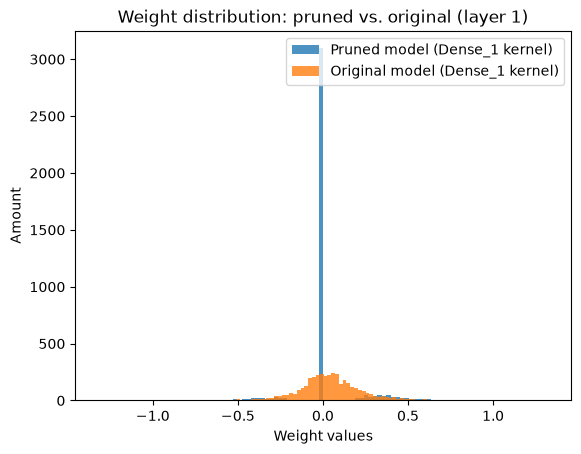

The saved memory space by pruning is 78.947%
The accuracy drop is 17.870%


In [257]:
# load lib
# if something goes wrong
# run pip install tensorflow==2.4.1
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude
# parameters for training the pruned model
batch_size = 32
epochs = 10
num_images = 60000

end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs
# Define model for pruning.
pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.00,
                                                               final_sparsity=0.80,
                                                               begin_step=3000,
                                                               end_step=end_step)
}
pruned_model = clone_model(model)
pruned_model = prune_low_magnitude(pruned_model, **pruning_params)
# `prune_low_magnitude` requires a recompile.
pruned_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

pruned_model.summary()
# Keras callback which updates pruning wrappers with the optimizer step.
# This callback must be used when training a model which needs to be pruned.
callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
]

history = pruned_model.fit(data_train,
                           label_train,
                           batch_size=batch_size,
                           epochs=epochs,
                           validation_split=0.20,
                           callbacks=callbacks)
acc_pruned_model = pruned_model.evaluate(data_test, label_test)[1]
pruned_model.summary()

# display the weights in 1st layer of the pruned model
# In the pruned model, index [1] is the kernel of Dense_1 (index [0] is a pruning wrapper variable).
# Index [3] is the corresponding binary mask (0=pruned, 1=kept).
plt.figure()
_ = plt.hist((pruned_model.get_weights()[1]).flatten(), bins=100, label='Pruned model (Dense_1 kernel)', alpha=0.8)
_ = plt.hist((model.get_weights()[0]).flatten(),        bins=100, label='Original model (Dense_1 kernel)', alpha=0.8)
plt.xlabel('Weight values')
plt.ylabel('Amount')
plt.title('Weight distribution: pruned vs. original (layer 1)')
plt.legend()
plt.show()

# calculate the saved memory
# simple assumption: "0" doesn't occupy the space
# Kernel weight counts from the original model (biases are not pruned → excluded).
# Original model kernels are at even indices: [0]=Dense_1, [2]=Dense_2, [4]=Dense_3, [6]=Dense_4
weights_total = sum(model.get_weights()[i].size for i in [0, 2, 4, 6])

# In the pruned model get_weights() the pruning masks are at indices [3,9,15,21]
# (offset 3 inside each 6-entry block per layer: wrapper_var, kernel, bias, mask, threshold, step).
# The mask is binary: 1 = weight kept, 0 = weight pruned.
# Summing the mask gives the number of remaining (non-zero) kernel weights.
weights_pruned = 0
get_weights_idx = [3, 9, 15, 21]
for i in range(4):
    weights_pruned += pruned_model.get_weights()[get_weights_idx[i]].sum()

weights_pruned_remained = weights_pruned  # remaining (non-zero) kernel weights
acc_drop_prun = acc_floatingpoint - acc_pruned_model
print("The saved memory space by pruning is {:.3f}%".format((1 - weights_pruned_remained / weights_total) * 100))
print("The accuracy drop is {:.3f}%".format(acc_drop_prun * 100))


# Systematic evaluation

Trying final_sparsity = 0.1
  Test Acc: 0.9041
Trying final_sparsity = 0.2
  Test Acc: 0.9029
Trying final_sparsity = 0.3
  Test Acc: 0.9083
Trying final_sparsity = 0.4
  Test Acc: 0.9053
Trying final_sparsity = 0.5
  Test Acc: 0.9000
Trying final_sparsity = 0.6
  Test Acc: 0.8886
Trying final_sparsity = 0.7
  Test Acc: 0.8556
Trying final_sparsity = 0.8
  Test Acc: 0.4843
Trying final_sparsity = 0.9
  Test Acc: 0.1751


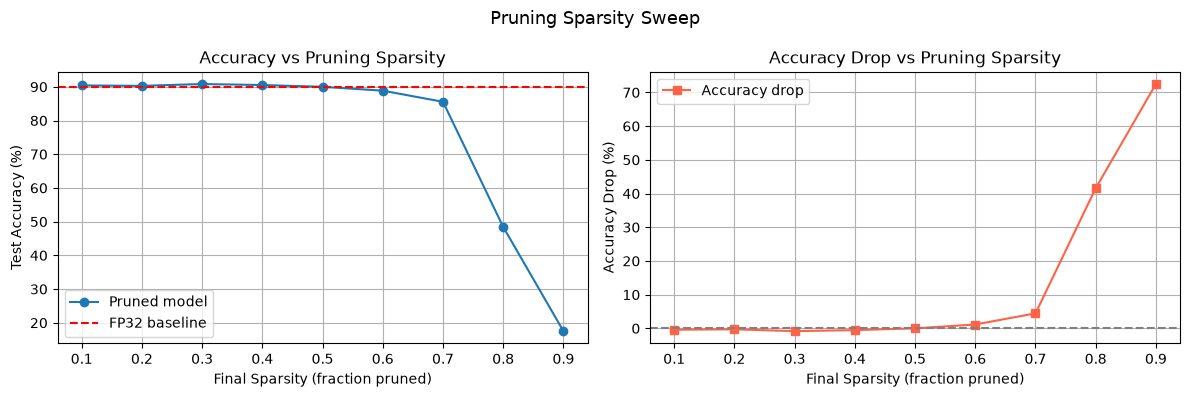


Sparsity       Test Acc (%)    Acc Drop (%)
-------------------------------------------
0.1                  90.410          -0.410
0.2                  90.290          -0.290
0.3                  90.830          -0.830
0.4                  90.530          -0.530
0.5                  90.000           0.000
0.6                  88.860           1.140
0.7                  85.560           4.440
0.8                  48.430          41.570
0.9                  17.510          72.490


In [260]:
sparisty_vec = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
acc_prun_vec = np.zeros(len(sparisty_vec))

for i in range(len(sparisty_vec)):
    print("Trying final_sparsity = {}".format(sparisty_vec[i]))
    # Define model for pruning with the current sparsity from the sweep vector.
    pruning_params = {
        'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.00,
            final_sparsity=sparisty_vec[i],   # sweep over sparsity values
            begin_step=3000,
            end_step=end_step,
        )
    }

    pruned_model = prune_low_magnitude(model, **pruning_params)

    pruned_model.compile(optimizer='adam',
                         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                         metrics=['accuracy'])

    callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]

    history = pruned_model.fit(data_train,
                               label_train,
                               batch_size=batch_size,
                               epochs=epochs,
                               validation_split=0.20,
                               callbacks=callbacks,
                               verbose=0)

    acc_prun_vec[i] = pruned_model.evaluate(data_test, label_test, verbose=0)[1]
    print("  Test Acc: {:.4f}".format(acc_prun_vec[i]))

# --- Plot results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Accuracy vs Sparsity
axes[0].plot(sparisty_vec, acc_prun_vec * 100, 'o-', label='Pruned model')
axes[0].axhline(y=acc_floatingpoint * 100, color='r', linestyle='--', label='FP32 baseline')
axes[0].set_xlabel('Final Sparsity (fraction pruned)')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy vs Pruning Sparsity')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Accuracy Drop vs Sparsity
acc_drop_prun_vec = acc_floatingpoint - acc_prun_vec
axes[1].plot(sparisty_vec, acc_drop_prun_vec * 100, 's-', color='tomato', label='Accuracy drop')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Final Sparsity (fraction pruned)')
axes[1].set_ylabel('Accuracy Drop (%)')
axes[1].set_title('Accuracy Drop vs Pruning Sparsity')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Pruning Sparsity Sweep', fontsize=13)
plt.tight_layout()
plt.show()

# Print summary table
print("\n{:<12} {:>14} {:>15}".format("Sparsity", "Test Acc (%)", "Acc Drop (%)"))
print("-" * 43)
for s, a, d in zip(sparisty_vec, acc_prun_vec * 100, acc_drop_prun_vec * 100):
    print("{:<12.1f} {:>14.3f} {:>15.3f}".format(s, a, d))
